In [1]:

# ============================================================
# CELL 1 — INSTALL / IMPORTS / REPRODUCIBILITY
# ============================================================

import os
import sys
import glob
import time
import copy
import random
import math
from pathlib import Path

try:
    import timm
except ImportError:
    !pip install -q timm
    import timm

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducible training.
    # benchmark=False avoids nondeterministic algorithm selection.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("DEVICE")
print("=" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)


DEVICE
Device: cuda
GPU: Tesla T4
CUDA: 12.8
PyTorch: 2.11.0+cu128
timm: 1.0.29


In [2]:

# ============================================================
# CELL 2 — CONFIGURATION
# ============================================================

CLASS_NAMES = ["lung_aca", "lung_n", "lung_scc"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

# Training
MAX_EPOCHS = 20
PATIENCE = 4

# Regularization
DROPOUT = 0.20
LABEL_SMOOTHING = 0.10
WEIGHT_DECAY = 2e-2

# Differential LR:
# pretrained GhostNet backbone learns slowly,
# newly initialized ViT/head learns faster.
BACKBONE_LR = 3e-5
HEAD_LR = 1e-4

# Transformer
EMBED_DIM = 256
NUM_HEADS = 4
NUM_LAYERS = 1
FFN_DIM = 512

# Previous independently obtained baseline
BASELINE_TEST_ACCURACY = 97.667

CHECKPOINT_PATH = "/kaggle/working/ghostnet100_vit_regularized_best.pth"

print("Configuration loaded.")
print(f"Max epochs        : {MAX_EPOCHS}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Backbone LR       : {BACKBONE_LR}")
print(f"Head LR           : {HEAD_LR}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"Transformer drop. : {DROPOUT}")
print(f"Label smoothing   : {LABEL_SMOOTHING}")


Configuration loaded.
Max epochs        : 20
Batch size        : 16
Backbone LR       : 3e-05
Head LR           : 0.0001
Weight decay      : 0.02
Transformer drop. : 0.2
Label smoothing   : 0.1


In [4]:

# ============================================================
# CELL 3 — FIND LC25000 DATASET + STRATIFIED SPLIT
# ============================================================

def find_lung_dataset_root():
    search_roots = ["/kaggle/input", ".", "../input"]

    for base in search_roots:
        if not os.path.exists(base):
            continue

        for root, dirs, files in os.walk(base):
            if all(cls in dirs for cls in CLASS_NAMES):
                return Path(root)

    raise FileNotFoundError(
        f"Could not find folders: {CLASS_NAMES}"
    )

dataset_root = find_lung_dataset_root()
print("Dataset root:", dataset_root)

all_paths = []
all_labels = []

for class_name in CLASS_NAMES:
    folder = dataset_root / class_name

    paths = []
    for ext in ("*.jpeg", "*.jpg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        paths.extend(glob.glob(str(folder / ext)))

    for path in sorted(paths):
        all_paths.append(path)
        all_labels.append(CLASS_TO_IDX[class_name])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print("Total images:", len(all_paths))

# 70% train / 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
    shuffle=True
)

# 15% validation / 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels,
    shuffle=True
)

print("=" * 70)
print("STRATIFIED DATA SPLIT")
print("=" * 70)
print(f"Train      : {len(train_paths):,} ({len(train_paths)/len(all_paths)*100:.1f}%)")
print(f"Validation : {len(val_paths):,} ({len(val_paths)/len(all_paths)*100:.1f}%)")
print(f"Test       : {len(test_paths):,} ({len(test_paths)/len(all_paths)*100:.1f}%)")


Dataset root: /kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets
Total images: 15000
STRATIFIED DATA SPLIT
Train      : 10,500 (70.0%)
Validation : 2,250 (15.0%)
Test       : 2,250 (15.0%)


In [6]:

# ============================================================
# CELL 4 — DATASET + ANTI-OVERFITTING AUGMENTATION
# ============================================================

class LC25000Dataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert("RGB")
        label = int(self.labels[idx])

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


# Training augmentation:
# Histopathology images have no meaningful global orientation,
# so horizontal/vertical flips are reasonable.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    ),
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.10),
        ratio=(0.3, 3.3),
        value="random"
    )
])

# Validation and test MUST NOT contain random augmentation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset = LC25000Dataset(
    train_paths, train_labels, train_transform
)

val_dataset = LC25000Dataset(
    val_paths, val_labels, eval_transform
)

test_dataset = LC25000Dataset(
    test_paths, test_labels, eval_transform
)

pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    worker_init_fn=seed_worker,
    generator=loader_generator,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 657
Validation batches: 141
Test batches: 141


In [7]:

# ============================================================
# CELL 5 — GHOSTNET-100 + REGULARIZED VISION TRANSFORMER
# ============================================================

def create_ghostnet_backbone():
    try:
        # ImageNet pretrained weights are preferred.
        backbone = timm.create_model(
            "ghostnet_100",
            pretrained=True,
            num_classes=0,
            global_pool=""
        )
        print("[INFO] Loaded ImageNet-pretrained GhostNet-100.")
    except Exception as e:
        print("[WARNING] Could not load pretrained weights.")
        print("Reason:", str(e)[:300])
        print("[INFO] Falling back to randomly initialized GhostNet-100.")

        backbone = timm.create_model(
            "ghostnet_100",
            pretrained=False,
            num_classes=0,
            global_pool=""
        )

    return backbone


class GhostNet100ViTRegularized(nn.Module):

    def __init__(
        self,
        num_classes=3,
        embed_dim=256,
        num_heads=4,
        num_layers=1,
        ff_dim=512,
        dropout=0.20
    ):
        super().__init__()

        self.backbone = create_ghostnet_backbone()

        # Automatically determine the final feature-map channels
        # rather than assuming a fixed channel count.
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feature_map = self.backbone(dummy)

        if feature_map.ndim != 4:
            raise RuntimeError(
                f"Expected a 4-D feature map, got {feature_map.shape}"
            )

        backbone_channels = feature_map.shape[1]
        feature_h = feature_map.shape[2]
        feature_w = feature_map.shape[3]
        num_tokens = feature_h * feature_w

        print(
            f"GhostNet feature map: "
            f"{backbone_channels} x {feature_h} x {feature_w}"
        )

        # Convert CNN feature channels into transformer embedding.
        self.projection = nn.Sequential(
            nn.Conv2d(
                backbone_channels,
                embed_dim,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(embed_dim),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.zeros(1, num_tokens, embed_dim)
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Stronger regularization at the classifier head.
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )

    def forward(self, x):

        # CNN feature extraction
        x = self.backbone(x)

        # CNN -> transformer embedding
        x = self.projection(x)

        # B, C, H, W -> B, N, C
        x = x.flatten(2).transpose(1, 2)

        # Positional information
        x = x + self.pos_embedding

        # Transformer learns relationships among spatial tokens
        x = self.transformer(x)

        # Global token pooling
        x = x.mean(dim=1)

        # Classification
        return self.head(x)


model = GhostNet100ViTRegularized(
    num_classes=len(CLASS_NAMES),
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FFN_DIM,
    dropout=DROPOUT
).to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("=" * 70)
print("MODEL")
print("=" * 70)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

[INFO] Loaded ImageNet-pretrained GhostNet-100.
GhostNet feature map: 1280 x 7 x 7


/tmp/ipykernel_49/13858414.py:97: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


MODEL
Total parameters    : 4,803,143
Trainable parameters: 4,803,143


In [8]:

# ============================================================
# CELL 6 — OPTIMIZER, LABEL SMOOTHING, SCHEDULER
# ============================================================

# Differential learning rates:
# pretrained CNN backbone -> smaller LR
# new projection/Transformer/classifier -> larger LR

backbone_params = []
head_params = []

for name, parameter in model.named_parameters():

    if not parameter.requires_grad:
        continue

    if name.startswith("backbone."):
        backbone_params.append(parameter)
    else:
        head_params.append(parameter)

optimizer = optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": BACKBONE_LR
        },
        {
            "params": head_params,
            "lr": HEAD_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)

# Label smoothing reduces excessive confidence and helps
# generalization.
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
    eta_min=1e-6
)

print("Optimizer: AdamW")
print("Backbone LR:", BACKBONE_LR)
print("Head LR:", HEAD_LR)
print("Weight decay:", WEIGHT_DECAY)
print("Label smoothing:", LABEL_SMOOTHING)


Optimizer: AdamW
Backbone LR: 3e-05
Head LR: 0.0001
Weight decay: 0.02
Label smoothing: 0.1


In [9]:


# ============================================================
# CELL 7 — TRAIN / VALIDATION FUNCTIONS
# ============================================================

def run_one_epoch(model, loader, criterion, optimizer=None):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()

                # Prevent unusually large gradients from destabilizing
                # the Transformer/backbone.
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr_backbone": [],
    "lr_head": [],
    "epoch_time": []
}

best_val_acc = -np.inf
best_epoch = 0
best_state = None
epochs_without_improvement = 0

print("=" * 90)
print("STARTING REGULARIZED GHOSTNET-100 + VIT TRAINING")
print("=" * 90)

for epoch in range(1, MAX_EPOCHS + 1):

    start_time = time.time()

    train_loss, train_acc = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None
    )

    current_backbone_lr = optimizer.param_groups[0]["lr"]
    current_head_lr = optimizer.param_groups[1]["lr"]

    scheduler.step()

    epoch_time = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr_backbone"].append(current_backbone_lr)
    history["lr_head"].append(current_head_lr)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch [{epoch:02d}/{MAX_EPOCHS}] | "
        f"Train Loss: {train_loss:.5f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.5f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_head_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Best checkpoint is selected ONLY using validation accuracy.
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0

        best_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": best_val_acc,
                "class_names": CLASS_NAMES
            },
            CHECKPOINT_PATH
        )

        print(
            f"  --> BEST CHECKPOINT SAVED "
            f"(Val Acc: {best_val_acc:.2f}%)"
        )

    else:
        epochs_without_improvement += 1

        print(
            f"  --> No improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

        if epochs_without_improvement >= PATIENCE:
            print("  --> Early stopping triggered.")
            break

print("=" * 90)
print("TRAINING FINISHED")
print(f"Best epoch       : {best_epoch}")
print(f"Best val accuracy: {best_val_acc:.2f}%")
print(f"Checkpoint       : {CHECKPOINT_PATH}")
print("=" * 90)

# Restore best validation model
if best_state is not None:
    model.load_state_dict(best_state)


STARTING REGULARIZED GHOSTNET-100 + VIT TRAINING
Epoch [01/20] | Train Loss: 0.44039 | Train Acc: 91.93% | Val Loss: 0.35456 | Val Acc: 96.49% | LR: 1.00e-04 | Time: 169.5s
  --> BEST CHECKPOINT SAVED (Val Acc: 96.49%)
Epoch [02/20] | Train Loss: 0.37254 | Train Acc: 95.67% | Val Loss: 0.36340 | Val Acc: 96.53% | LR: 9.94e-05 | Time: 100.1s
  --> BEST CHECKPOINT SAVED (Val Acc: 96.53%)
Epoch [03/20] | Train Loss: 0.34838 | Train Acc: 97.24% | Val Loss: 0.30931 | Val Acc: 99.07% | LR: 9.76e-05 | Time: 99.7s
  --> BEST CHECKPOINT SAVED (Val Acc: 99.07%)
Epoch [04/20] | Train Loss: 0.33327 | Train Acc: 98.08% | Val Loss: 0.31752 | Val Acc: 98.71% | LR: 9.46e-05 | Time: 99.7s
  --> No improvement (1/4)
Epoch [05/20] | Train Loss: 0.32152 | Train Acc: 98.60% | Val Loss: 0.31135 | Val Acc: 99.02% | LR: 9.05e-05 | Time: 99.6s
  --> No improvement (2/4)
Epoch [06/20] | Train Loss: 0.31913 | Train Acc: 98.73% | Val Loss: 0.30106 | Val Acc: 99.47% | LR: 8.55e-05 | Time: 100.8s
  --> BEST CHECKPO

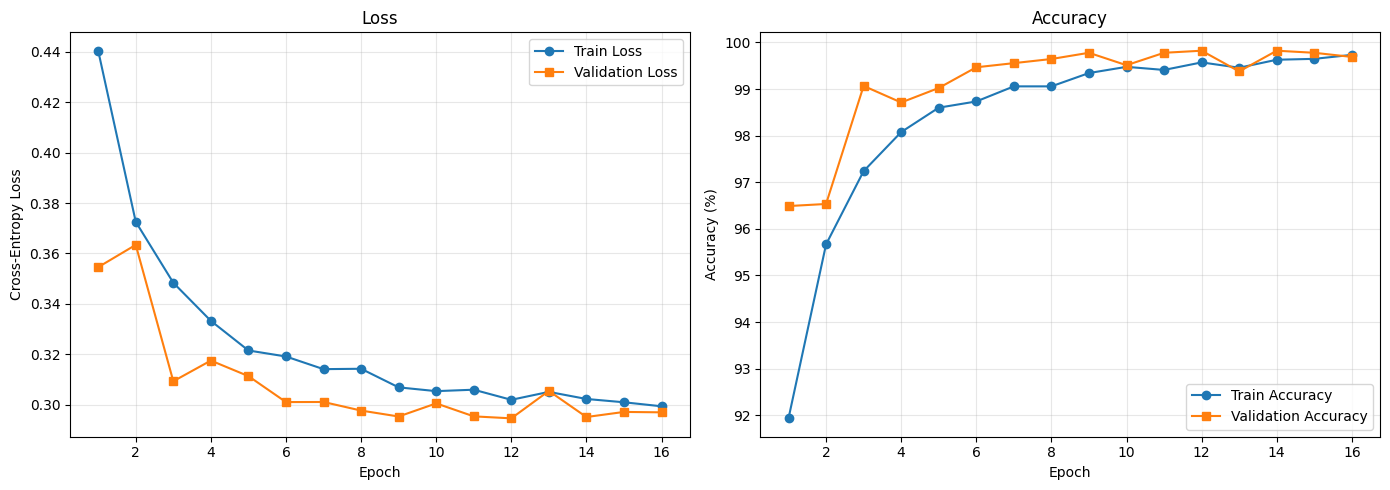

OVERFITTING CHECK
Final Train Accuracy      : 99.7333%
Final Validation Accuracy : 99.6889%
Train-Val Gap             : 0.0444 percentage points
Interpretation: train-validation gap is relatively controlled.


In [10]:

# ============================================================
# CELL 8 — TRAINING CURVES + OVERFITTING GAP
# ============================================================

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)
axes[0].plot(
    epochs,
    history["val_loss"],
    marker="s",
    label="Validation Loss"
)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Train Accuracy"
)
axes[1].plot(
    epochs,
    history["val_acc"],
    marker="s",
    label="Validation Accuracy"
)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "/kaggle/working/ghostnet100_vit_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]

print("=" * 70)
print("OVERFITTING CHECK")
print("=" * 70)
print(f"Final Train Accuracy      : {final_train_acc:.4f}%")
print(f"Final Validation Accuracy : {final_val_acc:.4f}%")
print(f"Train-Val Gap             : {final_train_acc-final_val_acc:.4f} percentage points")

if final_train_acc - final_val_acc > 5:
    print("Interpretation: noticeable overfitting.")
else:
    print("Interpretation: train-validation gap is relatively controlled.")


In [11]:

# ============================================================
# CELL 9 — FINAL INDEPENDENT TEST EVALUATION
# ============================================================

def evaluate_test(model, loader):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    total_inference_time = 0.0
    total_images = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()

            logits = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            total_inference_time += time.perf_counter() - start

            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            all_labels.extend(labels.numpy().tolist())
            all_predictions.extend(
                predictions.cpu().numpy().tolist()
            )
            all_probabilities.extend(
                probabilities.cpu().numpy().tolist()
            )

            total_images += images.size(0)

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    y_prob = np.array(all_probabilities)

    accuracy = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    recall_macro = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    f1_macro = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES)))
    )

    # One-vs-rest specificity for each class
    specificities = []

    for i in range(len(CLASS_NAMES)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        specificities.append(specificity)

    # ROC-AUC may fail if a class is absent, so handle safely.
    try:
        roc_auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        roc_auc = float("nan")

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "specificities": specificities,
        "roc_auc": roc_auc,
        "cm": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "inference_ms_per_image":
            (total_inference_time / total_images) * 1000
    }


results = evaluate_test(model, test_loader)

test_accuracy = results["accuracy"] * 100

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print(f"Test Accuracy       : {test_accuracy:.4f}%")
print(f"Macro Precision     : {results['precision_macro']*100:.4f}%")
print(f"Macro Recall        : {results['recall_macro']*100:.4f}%")
print(f"Macro F1            : {results['f1_macro']*100:.4f}%")
print(f"Macro ROC-AUC       : {results['roc_auc']:.6f}")
print(
    f"Inference/image     : "
    f"{results['inference_ms_per_image']:.4f} ms"
)

print("\nClassification Report:")
print(
    classification_report(
        results["y_true"],
        results["y_pred"],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(results["cm"])

print("\nPer-class specificity:")
for name, spec in zip(CLASS_NAMES, results["specificities"]):
    print(f"{name:<12}: {spec*100:.4f}%")


FINAL TEST RESULTS
Test Accuracy       : 99.6889%
Macro Precision     : 99.6889%
Macro Recall        : 99.6889%
Macro F1            : 99.6889%
Macro ROC-AUC       : 0.999991
Inference/image     : 1.1512 ms

Classification Report:
              precision    recall  f1-score   support

    lung_aca     0.9947    0.9960    0.9953       750
      lung_n     1.0000    1.0000    1.0000       750
    lung_scc     0.9960    0.9947    0.9953       750

    accuracy                         0.9969      2250
   macro avg     0.9969    0.9969    0.9969      2250
weighted avg     0.9969    0.9969    0.9969      2250

Confusion Matrix:
[[747   0   3]
 [  0 750   0]
 [  4   0 746]]

Per-class specificity:
lung_aca    : 99.7333%
lung_n      : 100.0000%
lung_scc    : 99.8000%


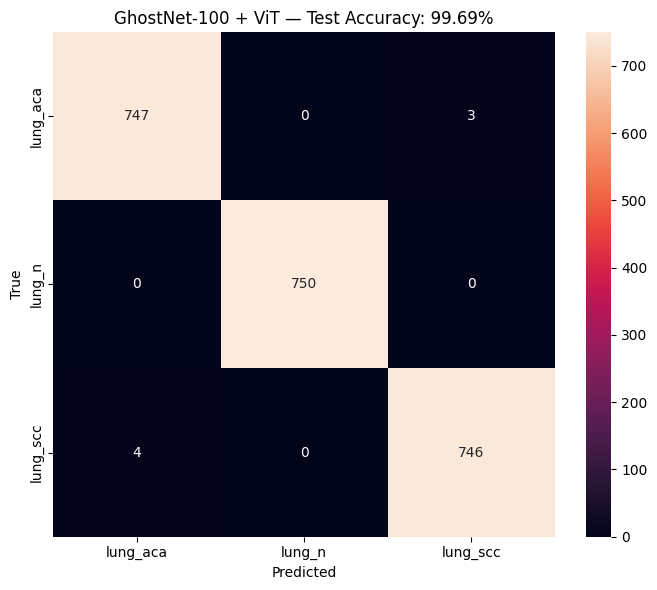

BASELINE VS ENHANCED MODEL
GhostNet-100 baseline : 97.667%
Regularized GhostNet + ViT: 99.689%
Accuracy change       : +2.022 percentage points
Relative error change : +86.66%
RESULT: Enhanced model improved over the baseline.


In [12]:

# ============================================================
# CELL 10 — CONFUSION MATRIX + BASELINE COMPARISON
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    results["cm"],
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    f"GhostNet-100 + ViT — Test Accuracy: {test_accuracy:.2f}%"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/ghostnet100_vit_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

delta = test_accuracy - BASELINE_TEST_ACCURACY

baseline_error = 100 - BASELINE_TEST_ACCURACY
new_error = 100 - test_accuracy

if baseline_error > 0:
    error_reduction = (
        (baseline_error - new_error) / baseline_error
    ) * 100
else:
    error_reduction = 0

print("=" * 70)
print("BASELINE VS ENHANCED MODEL")
print("=" * 70)
print(f"GhostNet-100 baseline : {BASELINE_TEST_ACCURACY:.3f}%")
print(f"Regularized GhostNet + ViT: {test_accuracy:.3f}%")
print(f"Accuracy change       : {delta:+.3f} percentage points")
print(f"Relative error change : {error_reduction:+.2f}%")

if delta > 0:
    print("RESULT: Enhanced model improved over the baseline.")
elif delta == 0:
    print("RESULT: Same accuracy as the baseline.")
else:
    print("RESULT: Enhanced model did not beat the baseline in this run.")
    print("Do not claim improvement; use the measured result.")


In [13]:

# ============================================================
# CELL 11 — SAVE RESULTS FOR YOUR PROJECT
# ============================================================

results_table = pd.DataFrame([{
    "Model": "GhostNet-100 + Regularized ViT",
    "Best Epoch": best_epoch,
    "Best Validation Accuracy (%)": best_val_acc,
    "Final Train Accuracy (%)": history["train_acc"][-1],
    "Final Validation Accuracy (%)": history["val_acc"][-1],
    "Test Accuracy (%)": test_accuracy,
    "Macro Precision (%)": results["precision_macro"] * 100,
    "Macro Recall (%)": results["recall_macro"] * 100,
    "Macro F1 (%)": results["f1_macro"] * 100,
    "Macro ROC-AUC": results["roc_auc"],
    "Baseline Test Accuracy (%)": BASELINE_TEST_ACCURACY,
    "Accuracy Delta (percentage points)": delta,
    "Train-Val Gap (percentage points)":
        history["train_acc"][-1] - history["val_acc"][-1]
}])

display(results_table)

results_table.to_csv(
    "/kaggle/working/ghostnet100_vit_regularized_results.csv",
    index=False
)

print("=" * 70)
print("FILES SAVED")
print("=" * 70)
print(CHECKPOINT_PATH)
print("/kaggle/working/ghostnet100_vit_training_curves.png")
print("/kaggle/working/ghostnet100_vit_confusion_matrix.png")
print("/kaggle/working/ghostnet100_vit_regularized_results.csv")


,Model,Best Epoch,Best Validation Accuracy (%),Final Train Accuracy (%),Final Validation Accuracy (%),Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Macro ROC-AUC,Baseline Test Accuracy (%),Accuracy Delta (percentage points),Train-Val Gap (percentage points)
0,GhostNet-100 + Regularized ViT,12,99.822222,99.733333,99.688889,99.688889,99.688948,99.688889,99.688889,0.999991,97.667,2.021889,0.044444


FILES SAVED
/kaggle/working/ghostnet100_vit_regularized_best.pth
/kaggle/working/ghostnet100_vit_training_curves.png
/kaggle/working/ghostnet100_vit_confusion_matrix.png
/kaggle/working/ghostnet100_vit_regularized_results.csv
